# Explorative Datenanalyse (EDA) und Preprocessing
**Ziel:** Verständnis für den "Online Shoppers Intention" Datensatz aufbauen, Datenqualität sichern und Features für die Modellierung (Conversion Prediction) ableiten.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Styling für Plots
sns.set_theme(style="whitegrid")

# Daten aus dem lokalen Verzeichnis laden
df = pd.read_csv('../data/online_shoppers_intention.csv')
print("Daten erfolgreich geladen!")

Daten erfolgreich geladen!


### 1. & 2. Datensatzgröße, Spalten, Datentypen und Analyse der Zielvariable
Wir prüfen die grundlegende Struktur und untersuchen unsere Zielvariable `Revenue` auf Klassenbalance.

--- DATENSATZ STRUKTUR ---
Zeilen: 12330, Spalten: 18

--- DATENTYPEN & FEHLENDE WERTE ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null

C:\Users\AW19263\AppData\Local\Temp\ipykernel_29908\3142776736.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Revenue', palette='Set2')


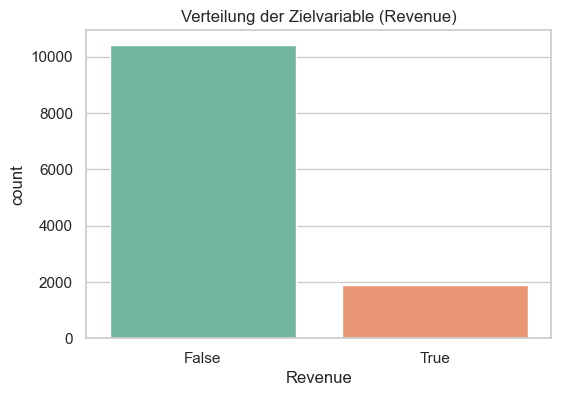


Klassenbalance:
Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64


In [2]:
# 1. Struktur & Qualität
print("--- DATENSATZ STRUKTUR ---")
print(f"Zeilen: {df.shape[0]}, Spalten: {df.shape[1]}")
print("\n--- DATENTYPEN & FEHLENDE WERTE ---")
df.info()

# 2. Analyse der Zielvariable (Revenue)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Revenue', palette='Set2')
plt.title('Verteilung der Zielvariable (Revenue)')
plt.show()

print("\nKlassenbalance:")
print(df['Revenue'].value_counts(normalize=True) * 100)

### 3. & 4. Zentrale Eingangsvariablen und Zusammenhänge
Wir betrachten Metriken wie `PageValues` (Wert der besuchten Seiten) und `BounceRates` (Absprungrate) und deren direkten Einfluss auf die Conversion (`Revenue`).

,PageValues,BounceRates,ProductRelated_Duration
count,12330.000000,12330.000000,12330.000000
mean,5.889258,0.022191,1194.746220
std,18.568437,0.048488,1913.669288
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,184.137500
50%,0.000000,0.003112,598.936905
75%,0.000000,0.016813,1464.157214
max,361.763742,0.200000,63973.522230


C:\Users\AW19263\AppData\Local\Temp\ipykernel_29908\255949934.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Revenue', y='PageValues', ax=axes[0], palette='Set2')


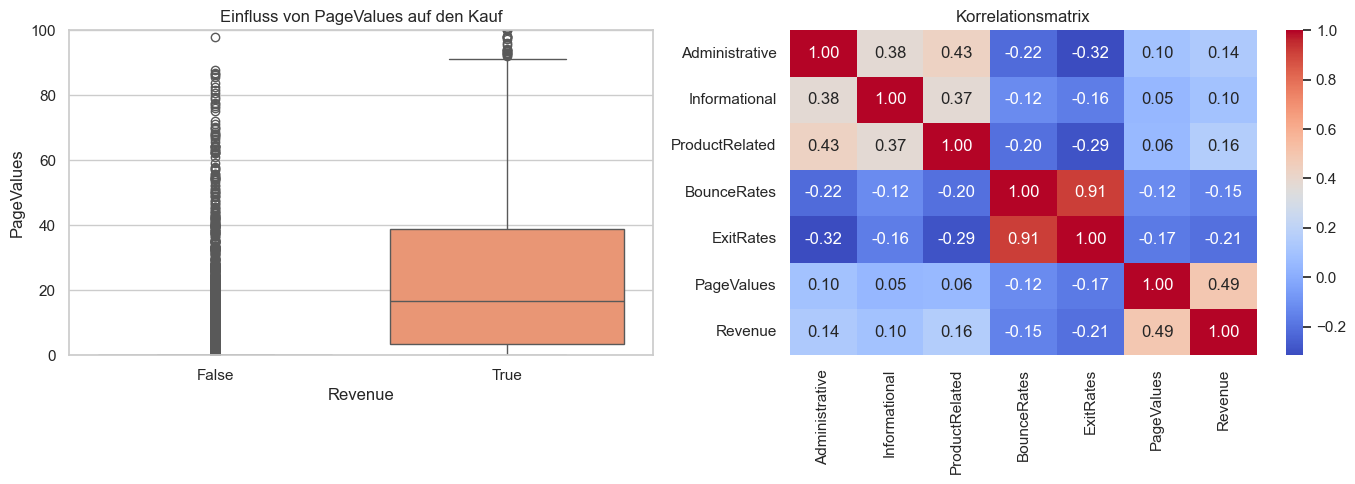

In [3]:
# 3. Deskriptive Statistik der zentralen numerischen Features
display(df[['PageValues', 'BounceRates', 'ProductRelated_Duration']].describe())

# 4. Zusammenhänge zwischen Merkmalen und Zielvariable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: PageValues vs. Revenue (Oft der stärkste Indikator)
sns.boxplot(data=df, x='Revenue', y='PageValues', ax=axes[0], palette='Set2')
axes[0].set_title('Einfluss von PageValues auf den Kauf')
axes[0].set_ylim(0, 100) # Outlier für bessere Lesbarkeit abschneiden

# Plot B: Korrelationsmatrix der wichtigsten Features
numeric_cols = ['Administrative', 'Informational', 'ProductRelated', 'BounceRates', 'ExitRates', 'PageValues', 'Revenue']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('Korrelationsmatrix')

plt.tight_layout()
plt.show()

In [4]:
# 5. Duplikate prüfen
dupes = df.duplicated().sum()
print(f"Gefundene exakte Duplikate: {dupes}")

Gefundene exakte Duplikate: 125


### 5. Datenqualität, Duplikate & Leakage-Risiken
* **Duplikate:** Wir prüfen auf identische Zeilen. Im Web-Tracking können diese durch Fehlklicks oder Bot-Traffic entstehen.
* **Leakage-Risiken:** Das Feature `PageValues` korreliert extrem stark mit dem Ziel. Laut Datensatz-Dokumentation wird dieser Wert aus vergangenen Transaktionen abgeleitet. Er repräsentiert das Nutzerverhalten vor Abschluss und ist somit **kein** Leakage.

### 6. Drei EDA-Erkenntnisse & Technische Entscheidungen
1. **Erkenntnis:** Starke Klassenimbalance (84.5% False, 15.5% True).
   * **Entscheidung:** Wir nutzen `scale_pos_weight` im XGBoost/Random Forest und den F1-Score als Metrik, nicht Accuracy.
2. **Erkenntnis:** Starke Ausreißer in den Duration-Features (einige User sind extrem lange inaktiv auf der Seite).
   * **Entscheidung:** Wir verwenden robuste, baumbasierte Modelle (XGBoost), da diese Ausreißer gut verkraften, ohne dass wir die Daten strikt normalisieren müssen.
3. **Erkenntnis:** 125 exakte Duplikate im Datensatz vorhanden.
   * **Entscheidung:** Wir entfernen diese im Preprocessing-Schritt, um eine Überanpassung (Overfitting) an diese spezifischen Sessions zu vermeiden.

### 1. - 3. Cleaning, Feature Engineering und strikte Trennung
Wir setzen die Entscheidungen um, bereinigen die Daten und generieren fachlich sinnvolle Features (z.B. Holiday-Saison-Flag).

In [5]:
# Klare Trennung: Wir erstellen einen expliziten df_clean für das Preprocessing
df_clean = df.copy()

# 1. Cleaning: Duplikate entfernen
df_clean.drop_duplicates(inplace=True)

# 2. Feature Engineering mit Business-Bezug
# Feature A: Ist es Holiday-Season? (E-Commerce Treiber)
df_clean['Is_Holiday_Season'] = df_clean['Month'].isin(['Nov', 'Dec']).astype(int)

# Feature B: Gesamtaktivität auf der Seite zusammenfassen
df_clean['Total_Clicks'] = df_clean['Administrative'] + df_clean['Informational'] + df_clean['ProductRelated']

# Formatierung: Booleans zu Integern (0/1) umwandeln für ML-Kompatibilität
df_clean['Weekend'] = df_clean['Weekend'].astype(int)
df_clean['Revenue'] = df_clean['Revenue'].astype(int)

# Kategoriale Werte (Text) in maschinenlesbare Zahlen umwandeln (One-Hot-Encoding)
df_clean = pd.get_dummies(df_clean, columns=['Month', 'VisitorType'], drop_first=True)

print("Cleaning und Feature Engineering erfolgreich ausgeführt.")

Cleaning und Feature Engineering erfolgreich ausgeführt.


### 4. - 6. Endprüfung, offene Entscheidungen und Export für Peer Review
Wir prüfen das finale Datenset auf Konsistenz und frieren den Stand für das MLflow-Training ein.

**Offene Entscheidungen (für spätere Iterationen):**
* Sollen stark korrelierende Features (`BounceRates` und `ExitRates`) zusammengefasst werden, um Multikollinearität weiter zu senken?
* Sollen extreme Outlier in der Verweildauer (z.B. > 10 Stunden) gekappt werden (Clipping)?

In [6]:
# 4. Erneute Prüfung des resultierenden Datensatzes
print("--- FINALES DATENSET FÜR DAS TRAINING ---")
print(f"Form: {df_clean.shape}")
print(f"Fehlende Werte gesamt: {df_clean.isnull().sum().sum()}")
print("\nErste 3 Zeilen der finalen Features:")
display(df_clean.head(3))

# 6. Bereitstellung des Stands für Peer Review und Modell-Pipeline
output_path = '../data/processed_online_shoppers.csv'
df_clean.to_csv(output_path, index=False)
print(f"\n✅ Reproduzierbarer Datensatz gespeichert unter: {output_path}")

--- FINALES DATENSET FÜR DAS TRAINING ---
Form: (12205, 29)
Fehlende Werte gesamt: 0

Erste 3 Zeilen der finalen Features:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.0,0.0,0.1,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True



✅ Reproduzierbarer Datensatz gespeichert unter: ../data/processed_online_shoppers.csv
